## Visualize Structural and Functional Connectivity Matrices

This notebook loads the structural and functional connectivity matrices from the `matrixdata` folder and visualizes them as heatmaps, similar to the plots in `figure_2.py`.

/Users/quanwen/Documents/GitHub/SC-FC/venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


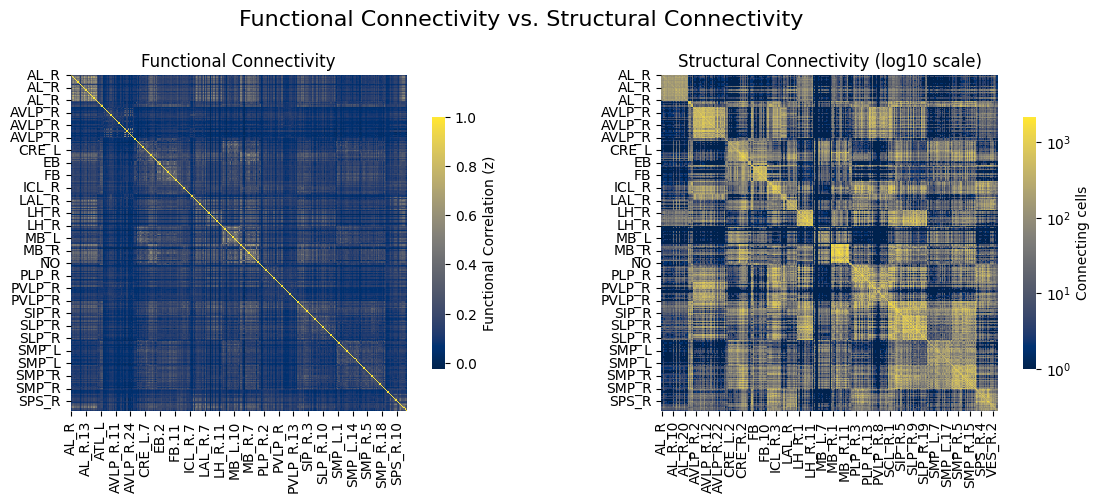

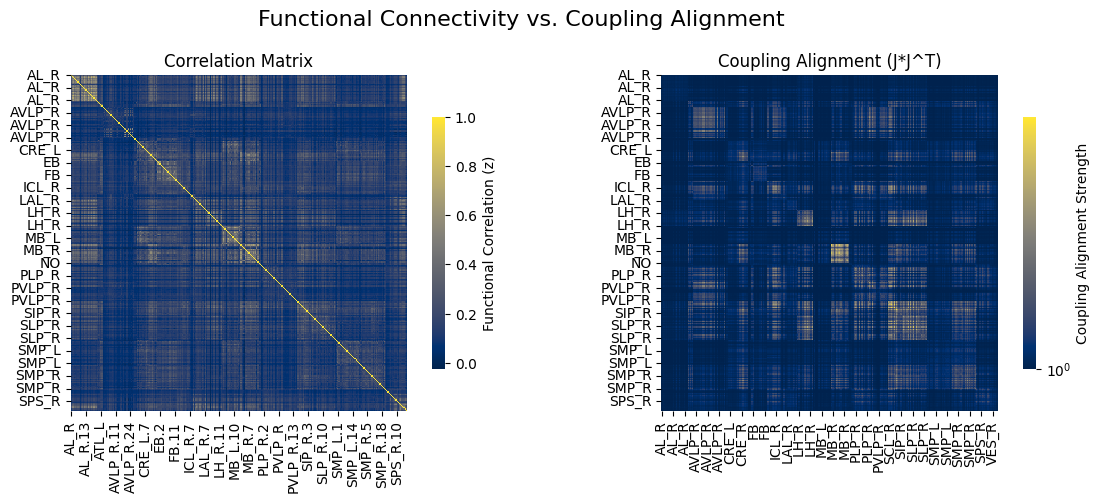

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import os

# This script assumes you have the scfc package installed and the data in the correct location.
# If you are running this from the root of the repository, the paths should be correct.
from scfc import bridge, subsampling

# --- 1. Load the data ---
data_dir = '/Users/quanwen/Documents/fly-center-brain/data'

# Load Functional Connectivity Matrix
functional_matrix_path = os.path.join(data_dir, 'CorrelationMatrix_branson.csv')
Functional_Matrix = pd.read_csv(functional_matrix_path, index_col=0)
vals = Functional_Matrix.to_numpy()
np.fill_diagonal(vals, 1)
Functional_Matrix.loc[:,:] = vals

# Load Structural Connectivity Matrix (J)
structural_matrix_path = os.path.join(data_dir, 'StructuralMatrix_branson.csv')
Structural_Matrix = pd.read_csv(structural_matrix_path, index_col=0)
vals = Structural_Matrix.to_numpy()
#np.fill_diagonal(vals, 0)
Structural_Matrix.loc[:, :] = vals

# --- 2. Plot Functional vs Structural ---
fig1, ax1 = plt.subplots(1, 2, figsize=(12, 5))
fig1.suptitle('Functional Connectivity vs. Structural Connectivity', fontsize=16)

# Functional heatmap
sns.heatmap(Functional_Matrix, ax=ax1[0],
            #yticklabels=False,
            #xticklabels=False,
            cbar_kws={'label': 'Functional Correlation (z)', 'shrink': .75}, cmap="cividis", rasterized=True)
ax1[0].set_title('Functional Connectivity')
ax1[0].set_aspect('equal')

# Structural heatmap
J_for_plotting = Structural_Matrix
#np.fill_diagonal(J_for_plotting.values, np.nan) # Replace diagonal with NaN for plotting
sns.heatmap(np.log10(J_for_plotting).replace([np.inf, -np.inf], 0), ax=ax1[1],
            #yticklabels=False,
            #xticklabels=False,
            cmap="cividis", rasterized=True, cbar=False)
cb1 = fig1.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.SymLogNorm(vmin=1, vmax=np.nanmax(J_for_plotting.to_numpy()), base=10, linthresh=0.1, linscale=1), cmap="cividis"), ax=ax1[1], shrink=0.75, label='Connecting cells')
cb1.outline.set_linewidth(0)
ax1[1].set_title('Structural Connectivity (log10 scale)')
ax1[1].set_aspect('equal')

fig1.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 3. Calculate Coupling Alignment Matrix (J * J^T) ---
J = Structural_Matrix
N = J.shape[0]
# Fill diagonal with 0 before matrix multiplication
#np.fill_diagonal(J.values, 0)
Coupling_Alignment = (J @ J.T)
Coupling_Alignment = Coupling_Alignment / np.trace(Coupling_Alignment) * N


# --- 4. Plot Functional vs Coupling Alignment ---
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('Functional Connectivity vs. Coupling Alignment', fontsize=16)

# Functional heatmap
sns.heatmap(Functional_Matrix, ax=ax2[0],
            #yticklabels=False,
            #xticklabels=False,
            cbar_kws={'label': 'Functional Correlation (z)', 'shrink': .75}, cmap="cividis", rasterized=True)
ax2[0].set_title('Correlation Matrix')
ax2[0].set_aspect('equal')

# Coupling Alignment heatmap
sns.heatmap(Coupling_Alignment, ax=ax2[1],
            #yticklabels=False,
            #xticklabels=False,
            cmap="cividis", rasterized=True, cbar=False)
cb2 = fig2.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.SymLogNorm(vmin=1, vmax=np.nanmax(Coupling_Alignment.to_numpy()), base=10, linthresh=0.1, linscale=1), cmap="cividis"), ax=ax2[1], shrink=0.75, label='Coupling Alignment Strength')
cb2.outline.set_linewidth(0)
ax2[1].set_title('Coupling Alignment (J*J^T)')
ax2[1].set_aspect('equal')

fig2.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


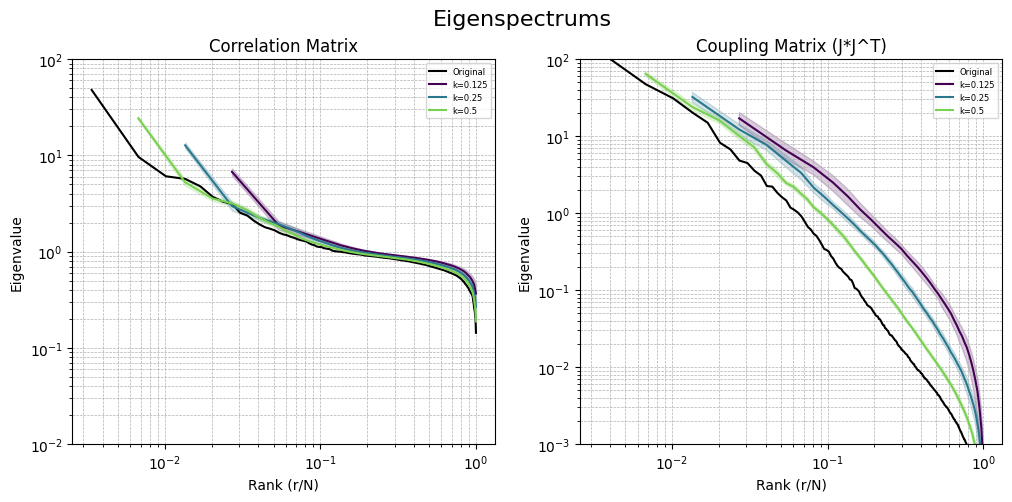

In [5]:
evals = np.linalg.eigvalsh(Functional_Matrix)
evals = np.sort(evals)[::-1]

k_fractions = [0.125, 0.25, 0.5]
n_iter = 50

fig3, ax3 = plt.subplots(1, 2, figsize=(12, 5))
fig3.suptitle('Eigenspectrums', fontsize=16)

ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax3[0].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')

colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(Functional_Matrix.to_numpy(), k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax3[0].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax3[0].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)


ax3[0].set_xlabel('Rank (r/N)')
ax3[0].set_ylabel('Eigenvalue')
ax3[0].set_ylim([10**-2, 10**2])
ax3[0].legend(fontsize=6)
ax3[0].set_title('Correlation Matrix')
ax3[0].grid(True, which='both', linestyle='--', linewidth=0.5)


evals = np.linalg.eigvalsh(Coupling_Alignment)
evals = np.sort(evals)[::-1]

ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax3[1].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')

colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(Coupling_Alignment.to_numpy(), k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax3[1].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax3[1].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)


ax3[1].set_xlabel('Rank (r/N)')
ax3[1].set_ylabel('Eigenvalue')
ax3[1].set_ylim([10**-3, 10**2])
ax3[1].legend(fontsize=6)
ax3[1].set_title('Coupling Matrix (J*J^T)')
ax3[1].grid(True, which='both', linestyle='--', linewidth=0.5)



plt.show()

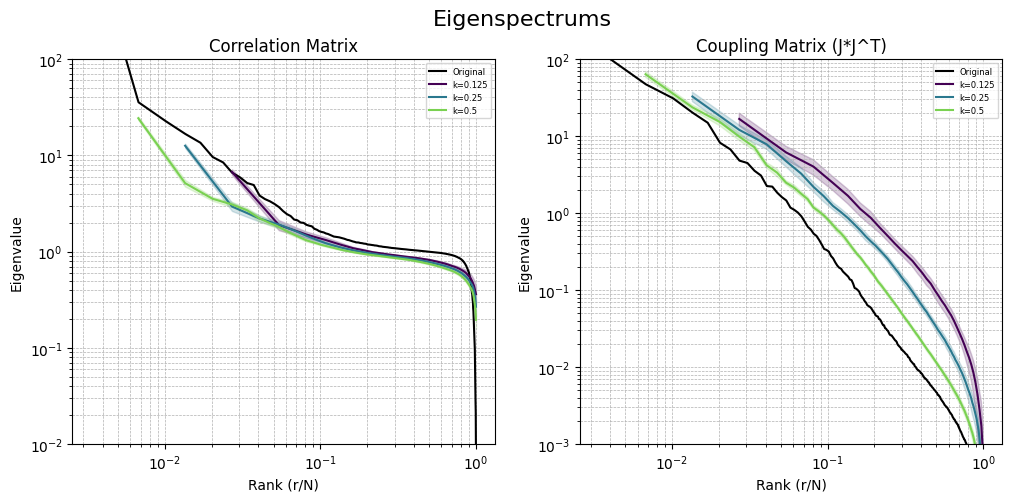

In [13]:
g = 1.0
W = subsampling.generate_W_matrix(Coupling_Alignment.to_numpy(),g)
Correlation_Matrix = subsampling.compute_functional_connectivity(W)

evals = np.linalg.eigvalsh(Correlation_Matrix)
evals = np.sort(evals)[::-1]

k_fractions = [0.125, 0.25, 0.5]
n_iter = 50

fig4, ax4 = plt.subplots(1, 2, figsize=(12, 5))
fig4.suptitle('Eigenspectrums', fontsize=16)

ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax4[0].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')

colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(Functional_Matrix.to_numpy(), k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax4[0].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax4[0].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)


ax4[0].set_xlabel('Rank (r/N)')
ax4[0].set_ylabel('Eigenvalue')
ax4[0].set_ylim([10**-2, 10**2])
ax4[0].legend(fontsize=6)
ax4[0].set_title('Correlation Matrix')
ax4[0].grid(True, which='both', linestyle='--', linewidth=0.5)


evals = np.linalg.eigvalsh(Coupling_Alignment)
evals = np.sort(evals)[::-1]

ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax4[1].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')

colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(Coupling_Alignment.to_numpy(), k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax4[1].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax4[1].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)


ax4[1].set_xlabel('Rank (r/N)')
ax4[1].set_ylabel('Eigenvalue')
ax4[1].set_ylim([10**-3, 10**2])
ax4[1].legend(fontsize=6)
ax4[1].set_title('Coupling Matrix (J*J^T)')
ax4[1].grid(True, which='both', linestyle='--', linewidth=0.5)

fig3.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()
